In [1]:
# loading libraries
!pip install xlrd

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [2]:
import pandas as pd

# Load the data
url = "https://www.eia.gov/petroleum/gasdiesel/xls/pswrgvwall.xls"
df_raw = pd.read_excel(url, sheet_name='Data 1', skiprows=2)

# Select columns: Date, US_Avg, East_Coast, Midwest, Gulf_Coast, Rocky_Mtn, West_Coast
# These indexes [0, 1, 2, 6, 7, 8, 9] correspond to the specific regions you requested
df = df_raw.iloc[:, [0, 1, 2, 6, 7, 8, 9]].copy()

# Rename to clean versions
df.columns = ['Date', 'US_Avg', 'East_Coast', 'Midwest', 'Gulf_Coast', 'Rocky_Mtn', 'West_Coast']

# Remove rows with empty price data
df = df.dropna()

# Convert Date to datetime format for the model
df['Date'] = pd.to_datetime(df['Date'])

# Show the first few rows to verify the columns
print("Data successfully loaded with requested regions:")
df.head()

Data successfully loaded with requested regions:


,Date,US_Avg,East_Coast,Midwest,Gulf_Coast,Rocky_Mtn,West_Coast
90,1992-05-11,1.102,1.071,1.103,1.084,1.117,1.189
91,1992-05-18,1.118,1.085,1.118,1.095,1.169,1.208
92,1992-05-25,1.120,1.092,1.117,1.094,1.159,1.218
93,1992-06-01,1.128,1.100,1.122,1.108,1.155,1.228
94,1992-06-08,1.143,1.114,1.137,1.120,1.178,1.246


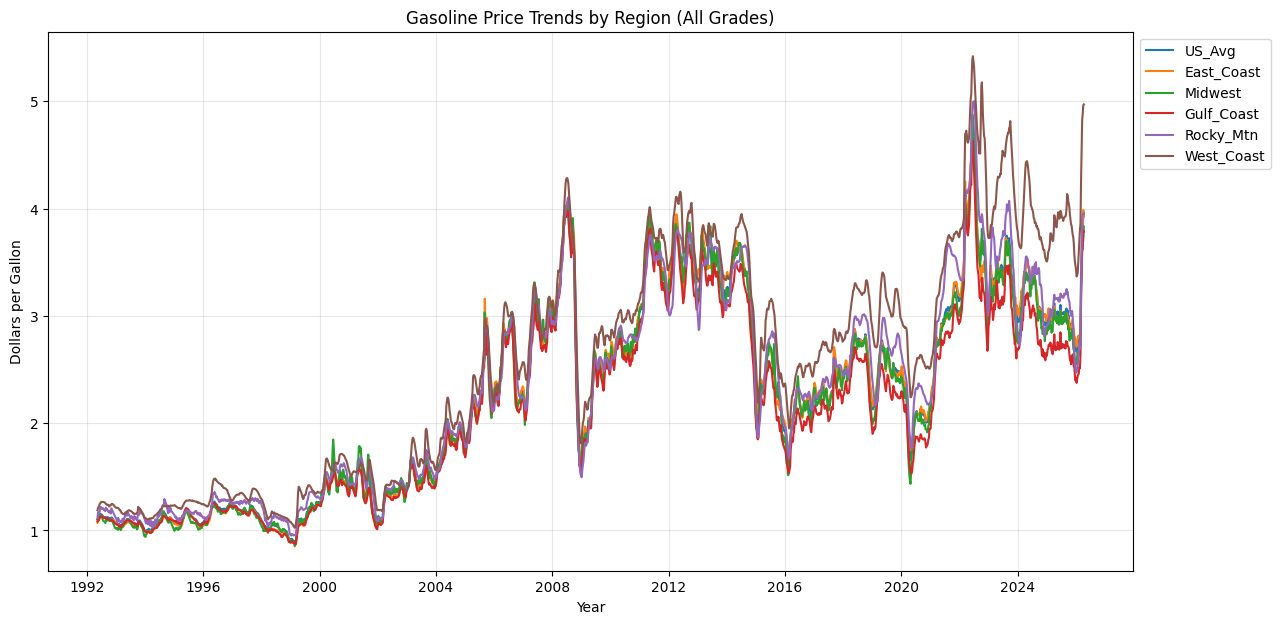

In [3]:
# all regions, full timeline
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
for column in df.columns[1:]:  # Skip the 'Date' column
    plt.plot(df['Date'], df[column], label=column)

plt.title('Gasoline Price Trends by Region (All Grades)')
plt.ylabel('Dollars per Gallon')
plt.xlabel('Year')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.show()


In [4]:
# Create a dictionary to hold the separate dataframes
region_data = {}

# List of regions (skipping 'Date')
regions = ['US_Avg', 'East_Coast', 'Midwest', 'Gulf_Coast', 'Rocky_Mtn', 'West_Coast']

# Loop through and create a clean dataframe for each region
for r in regions:
    # Select only the Date and the specific region's price
    region_df = df[['Date', r]].copy()

    # Rename the price column to a generic 'Price' so the model code
    # can work for any region without changing variable names
    region_df.columns = ['Date', 'Price']

    # Store it in the dictionary
    region_data[r] = region_df

# Example: Accessing just the West Coast data
print("West Coast Data Isolated:")
print(region_data['West_Coast'].head())

West Coast Data Isolated:
         Date  Price
90 1992-05-11  1.189
91 1992-05-18  1.208
92 1992-05-25  1.218
93 1992-06-01  1.228
94 1992-06-08  1.246


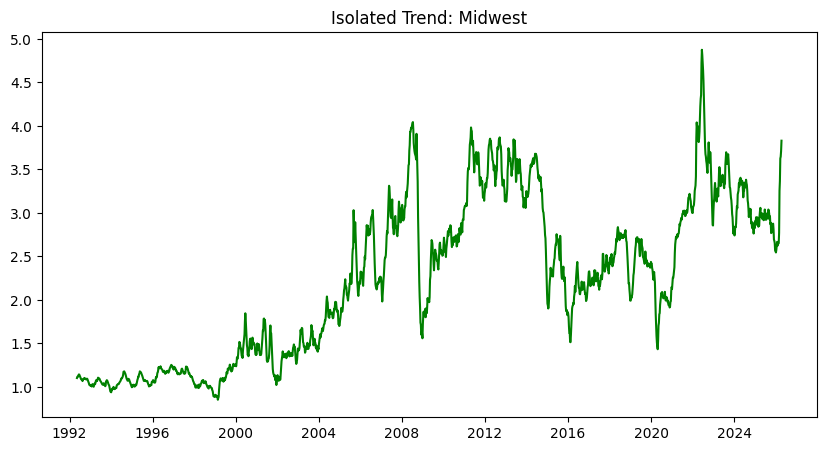

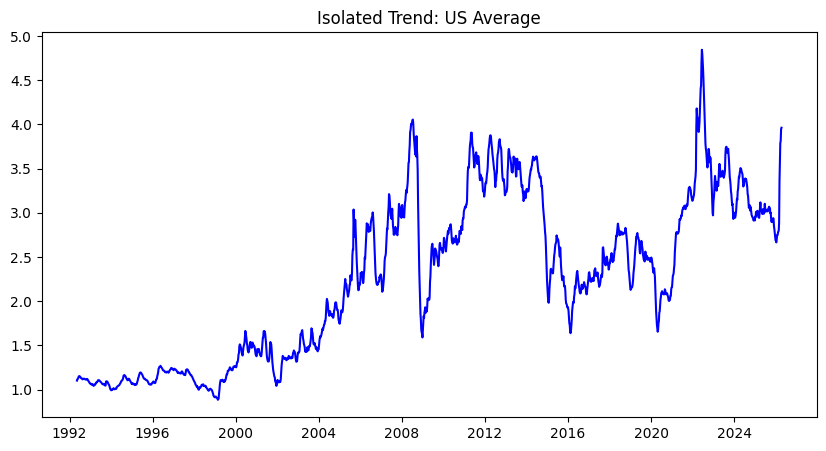

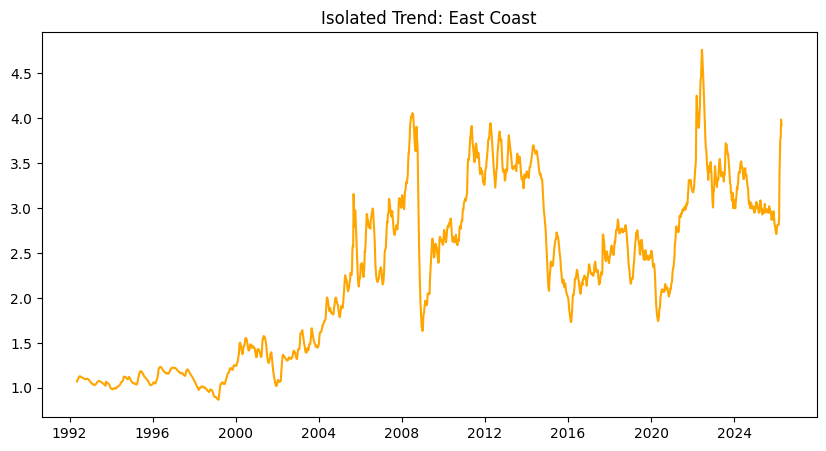

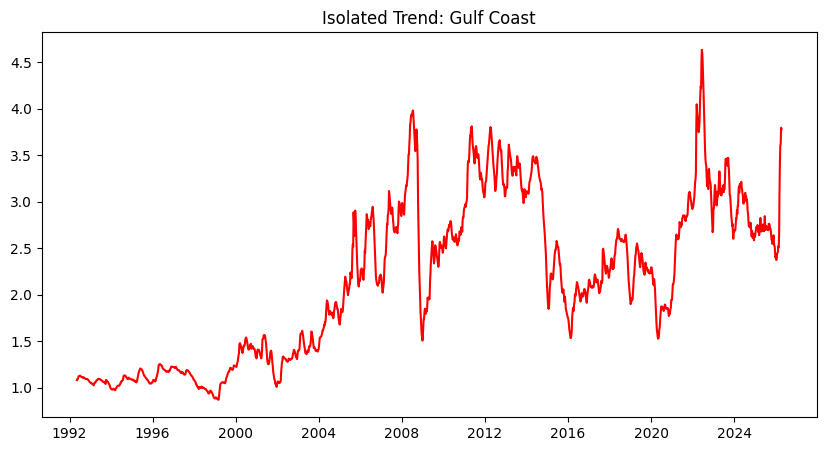

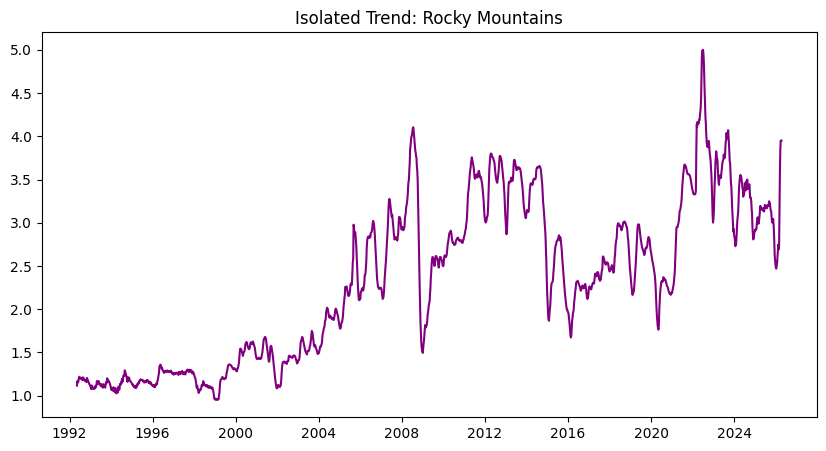

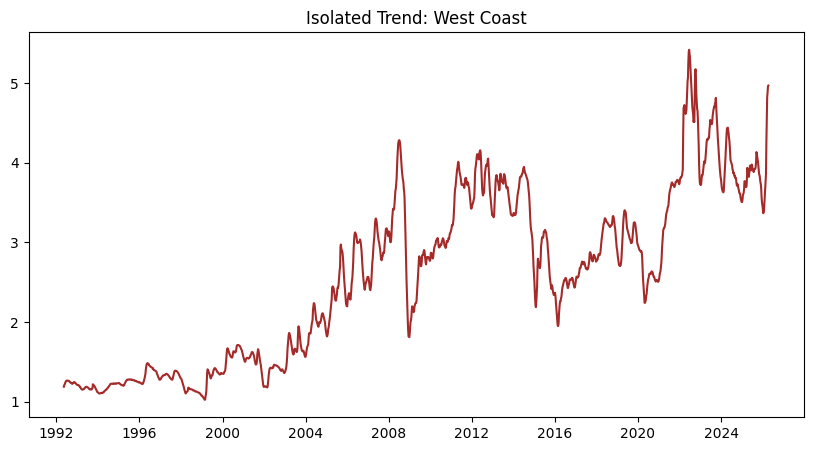

In [5]:
# isolated graphs
midwest_df = region_data['Midwest']

plt.figure(figsize=(10, 5))
plt.plot(midwest_df['Date'], midwest_df['Price'], color='green')
plt.title('Isolated Trend: Midwest')
plt.show()

midwest_df = region_data['US_Avg']

plt.figure(figsize=(10, 5))
plt.plot(midwest_df['Date'], midwest_df['Price'], color='blue')
plt.title('Isolated Trend: US Average')
plt.show()

midwest_df = region_data['East_Coast']

plt.figure(figsize=(10, 5))
plt.plot(midwest_df['Date'], midwest_df['Price'], color='orange')
plt.title('Isolated Trend: East Coast')
plt.show()

midwest_df = region_data['Gulf_Coast']

plt.figure(figsize=(10, 5))
plt.plot(midwest_df['Date'], midwest_df['Price'], color='red')
plt.title('Isolated Trend: Gulf Coast')
plt.show()

midwest_df = region_data['Rocky_Mtn']

plt.figure(figsize=(10, 5))
plt.plot(midwest_df['Date'], midwest_df['Price'], color='purple')
plt.title('Isolated Trend: Rocky Mountains')
plt.show()

midwest_df = region_data['West_Coast']

plt.figure(figsize=(10, 5))
plt.plot(midwest_df['Date'], midwest_df['Price'], color='brown')
plt.title('Isolated Trend: West Coast')
plt.show()

In [6]:
def predict_gas_price(region_name):
    data = region_data[region_name].copy()

    # Create Lag
    data['Lag1'] = data['Price'].shift(1)
    data = data.dropna()

    # Train Model
    model = LinearRegression()
    model.fit(data[['Lag1']], data['Price'])

    # Get the latest price to predict next week
    current_price = data['Price'].iloc[-1]
    prediction = model.predict([[current_price]])

    return prediction[0]

# Now you can get predictions for any region instantly!
for r in regions:
    p = predict_gas_price(r)
    print(f"Predicted next week price for {r}: ${p:.3f}")

Predicted next week price for US_Avg: $3.962
Predicted next week price for East_Coast: $3.925
Predicted next week price for Midwest: $3.829
Predicted next week price for Gulf_Coast: $3.782
Predicted next week price for Rocky_Mtn: $3.951
Predicted next week price for West_Coast: $4.972


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/

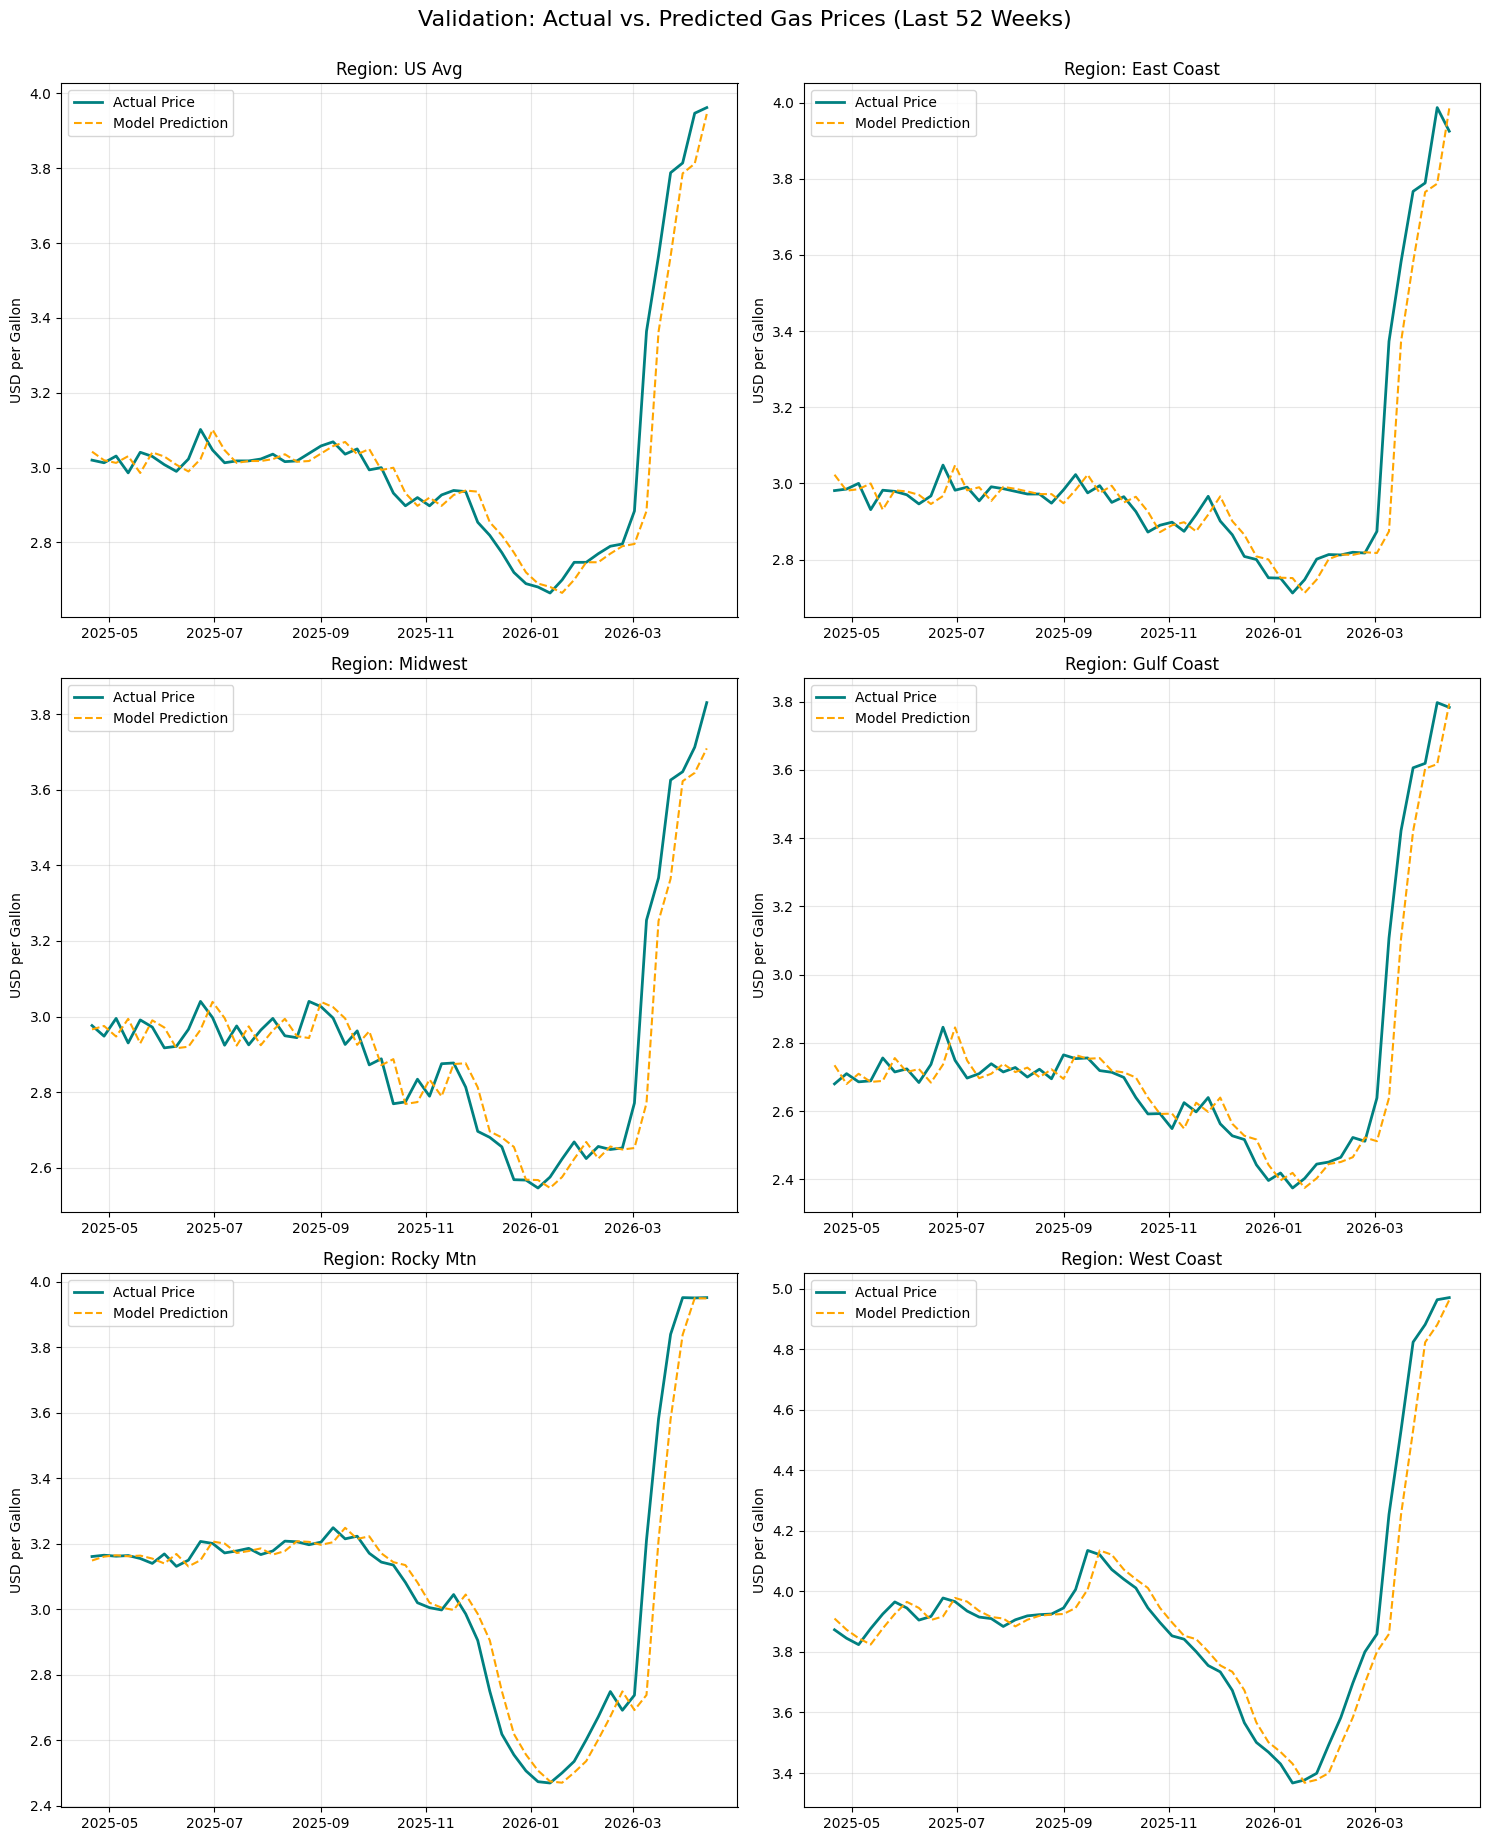

In [7]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Setup the plot (3 rows, 2 columns for our 6 regions)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 18))
axes = axes.flatten()
regions = ['US_Avg', 'East_Coast', 'Midwest', 'Gulf_Coast', 'Rocky_Mtn', 'West_Coast']

# 2. Loop through each region and create the prediction visualization
for i, r in enumerate(regions):
    data = region_data[r].copy()

    # Feature Engineering: Lag 1 (Price of the previous week)
    data['Lag1'] = data['Price'].shift(1)
    data = data.dropna()

    # Split data: Train on everything except the last 52 weeks
    train = data.iloc[:-52]
    test = data.iloc[-52:]

    # Train the Model
    model = LinearRegression()
    model.fit(train[['Lag1']], train['Price'])

    # Generate Predictions for the test year
    test_predictions = model.predict(test[['Lag1']])

    # 3. Plotting the results
    axes[i].plot(test['Date'], test['Price'], label='Actual Price', color='teal', linewidth=2)
    axes[i].plot(test['Date'], test_predictions, label='Model Prediction', color='orange', linestyle='--')

    # Formatting
    axes[i].set_title(f'Region: {r.replace("_", " ")}')
    axes[i].set_ylabel('USD per Gallon')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Validation: Actual vs. Predicted Gas Prices (Last 52 Weeks)', y=1.02, fontsize=16)
plt.show()

Generating 2026 isolated visualization for 15 weeks of data...


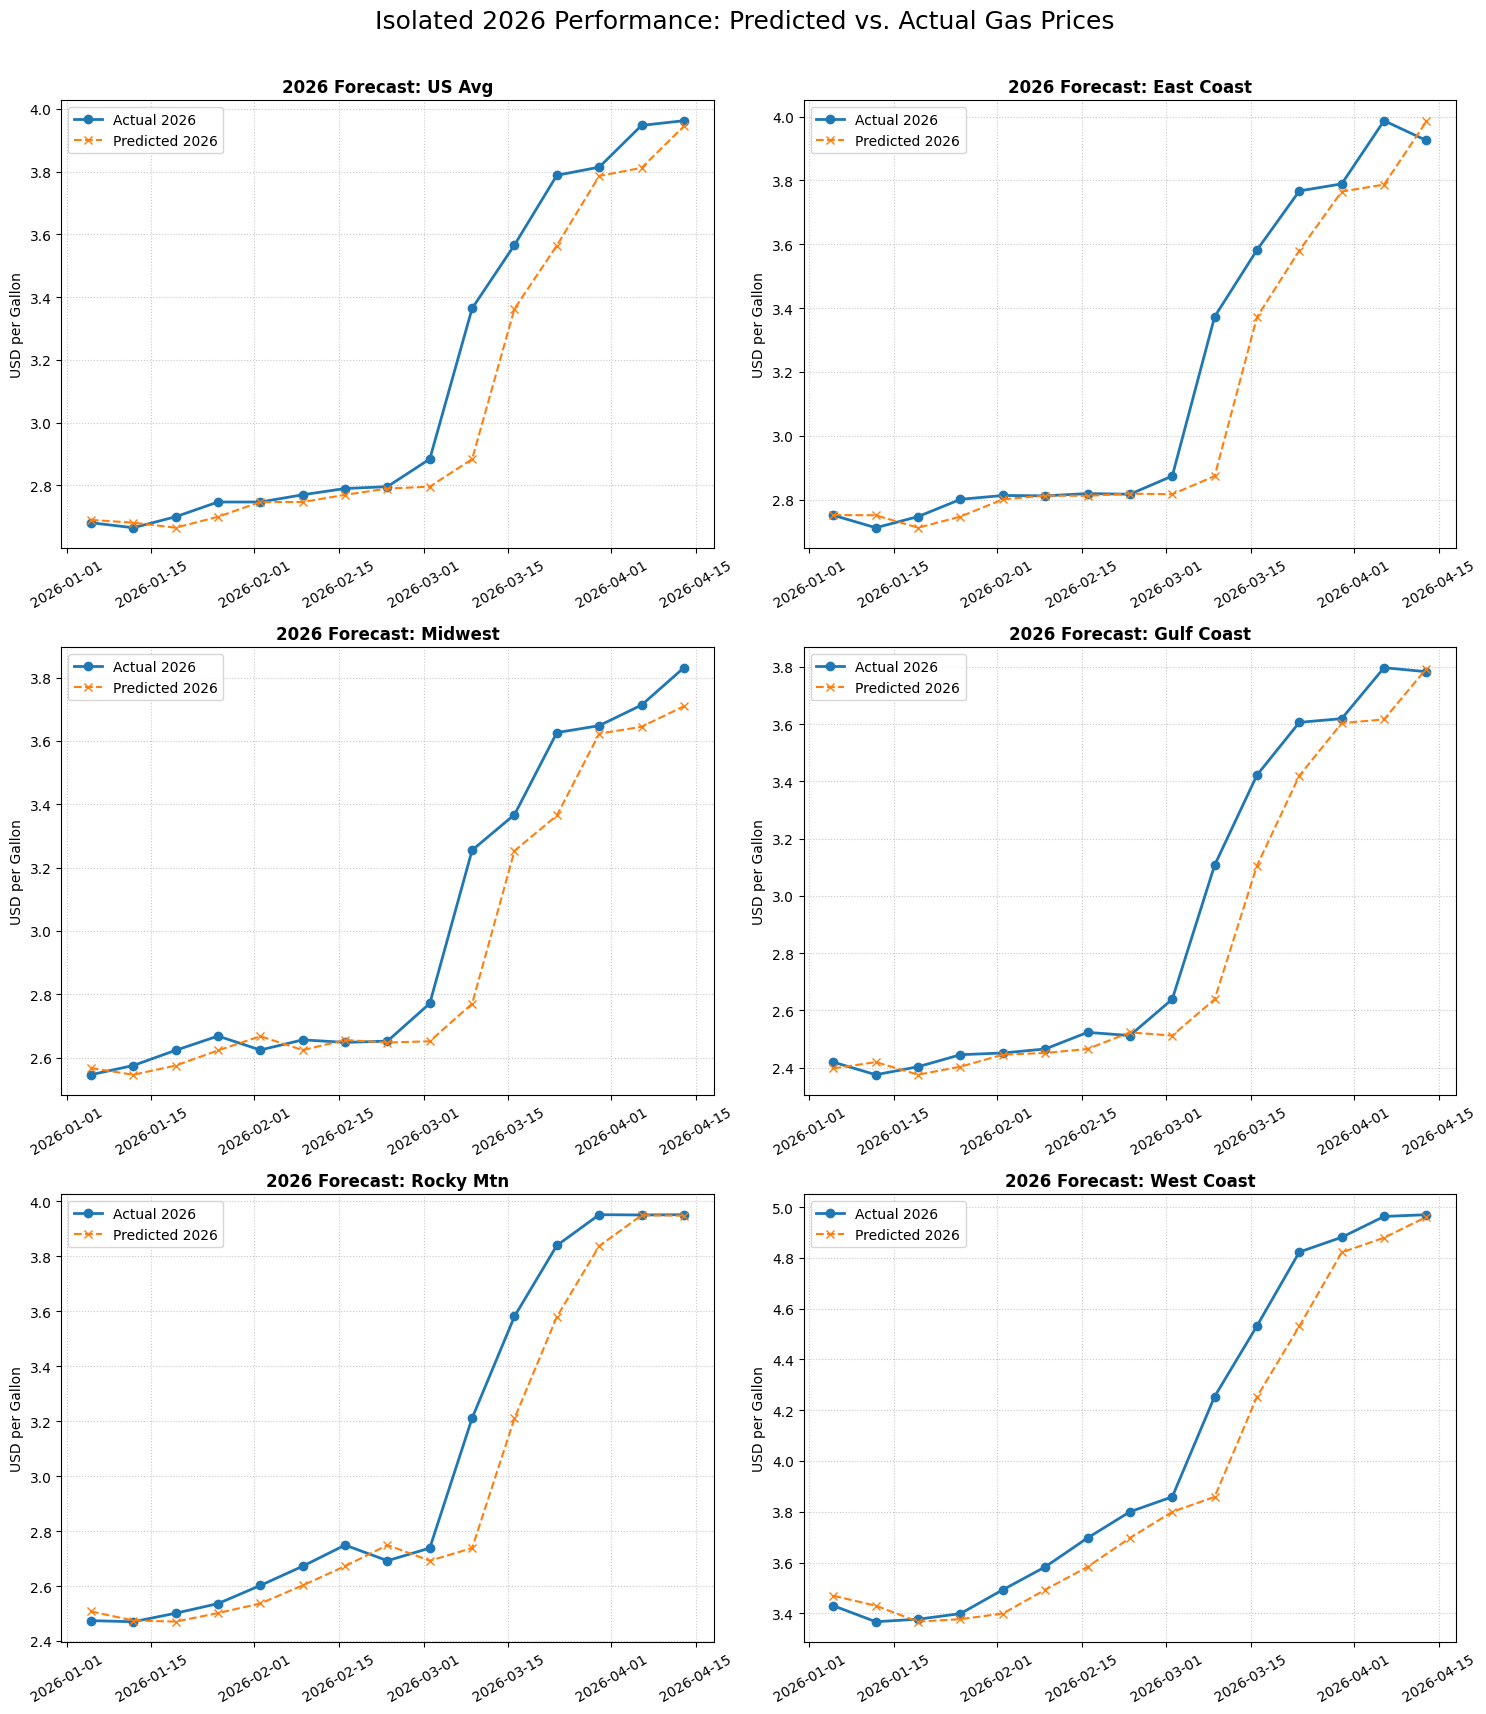

In [8]:
# predictions vs. data
#import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Filter for the year 2026
# We ensure the Date is in datetime format first
df['Date'] = pd.to_datetime(df['Date'])
df_2026 = df[df['Date'].dt.year == 2026].copy()

# 2. Setup the visualization grid
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 18))
axes = axes.flatten()
regions = ['US_Avg', 'East_Coast', 'Midwest', 'Gulf_Coast', 'Rocky_Mtn', 'West_Coast']

print(f"Generating 2026 isolated visualization for {len(df_2026)} weeks of data...")

# 3. Loop through regions to train and plot 2026 data
for i, r in enumerate(regions):
    # Get full history for training, but we will focus the 'Test' on 2026
    full_data = df[['Date', r]].copy()
    full_data.columns = ['Date', 'Price']
    full_data['Lag1'] = full_data['Price'].shift(1)
    full_data = full_data.dropna()

    # Split: Train on everything BEFORE 2026, Test on 2026
    train = full_data[full_data['Date'].dt.year < 2026]
    test_2026 = full_data[full_data['Date'].dt.year == 2026]

    # Check if we have 2026 data to plot
    if not test_2026.empty:
        model = LinearRegression()
        model.fit(train[['Lag1']], train['Price'])

        # Predict 2026 prices
        preds_2026 = model.predict(test_2026[['Lag1']])

        # Plotting
        axes[i].plot(test_2026['Date'], test_2026['Price'], marker='o', label='Actual 2026', color='#1f77b4', linewidth=2)
        axes[i].plot(test_2026['Date'], preds_2026, marker='x', label='Predicted 2026', color='#ff7f0e', linestyle='--')

        # Formatting each subplot
        axes[i].set_title(f'2026 Forecast: {r.replace("_", " ")}', fontsize=12, fontweight='bold')
        axes[i].set_ylabel('USD per Gallon')
        axes[i].grid(True, linestyle=':', alpha=0.7)
        axes[i].legend()

        # Clean up date display on X-axis
        plt.setp(axes[i].get_xticklabels(), rotation=30)

# Final Layout Adjustments
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle('Isolated 2026 Performance: Predicted vs. Actual Gas Prices', fontsize=18)
plt.show()

In [9]:
# prediction for the rest of 2026
import pandas as pd
import numpy as np
from datetime import timedelta

# Define the end of the year
end_of_year = pd.to_datetime('2026-12-31')
regions = ['US_Avg', 'East_Coast', 'Midwest', 'Gulf_Coast', 'Rocky_Mtn', 'West_Coast']

# Dictionary to store future data
future_forecasts = {}

for r in regions:
    # Prepare historical data
    data = df[['Date', r]].copy()
    data.columns = ['Date', 'Price']
    data['Lag1'] = data['Price'].shift(1)
    data = data.dropna()

    # Train model on all available data up to today
    model = LinearRegression()
    model.fit(data[['Lag1']], data['Price'])

    # Start recursive forecasting
    current_date = data['Date'].max()
    current_price = data['Price'].iloc[-1]

    future_dates = []
    future_prices = []

    # Loop until we hit the end of December
    while current_date < end_of_year:
        current_date += timedelta(days=7) # Add one week
        # Predict next price based on current
        next_price = model.predict([[current_price]])[0]

        future_dates.append(current_date)
        future_prices.append(next_price)

        # Update current price for the NEXT iteration
        current_price = next_price

    future_forecasts[r] = pd.DataFrame({'Date': future_dates, 'Price': future_prices})

print("Forecast complete for all regions through Dec 2026.")

Forecast complete for all regions through Dec 2026.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/

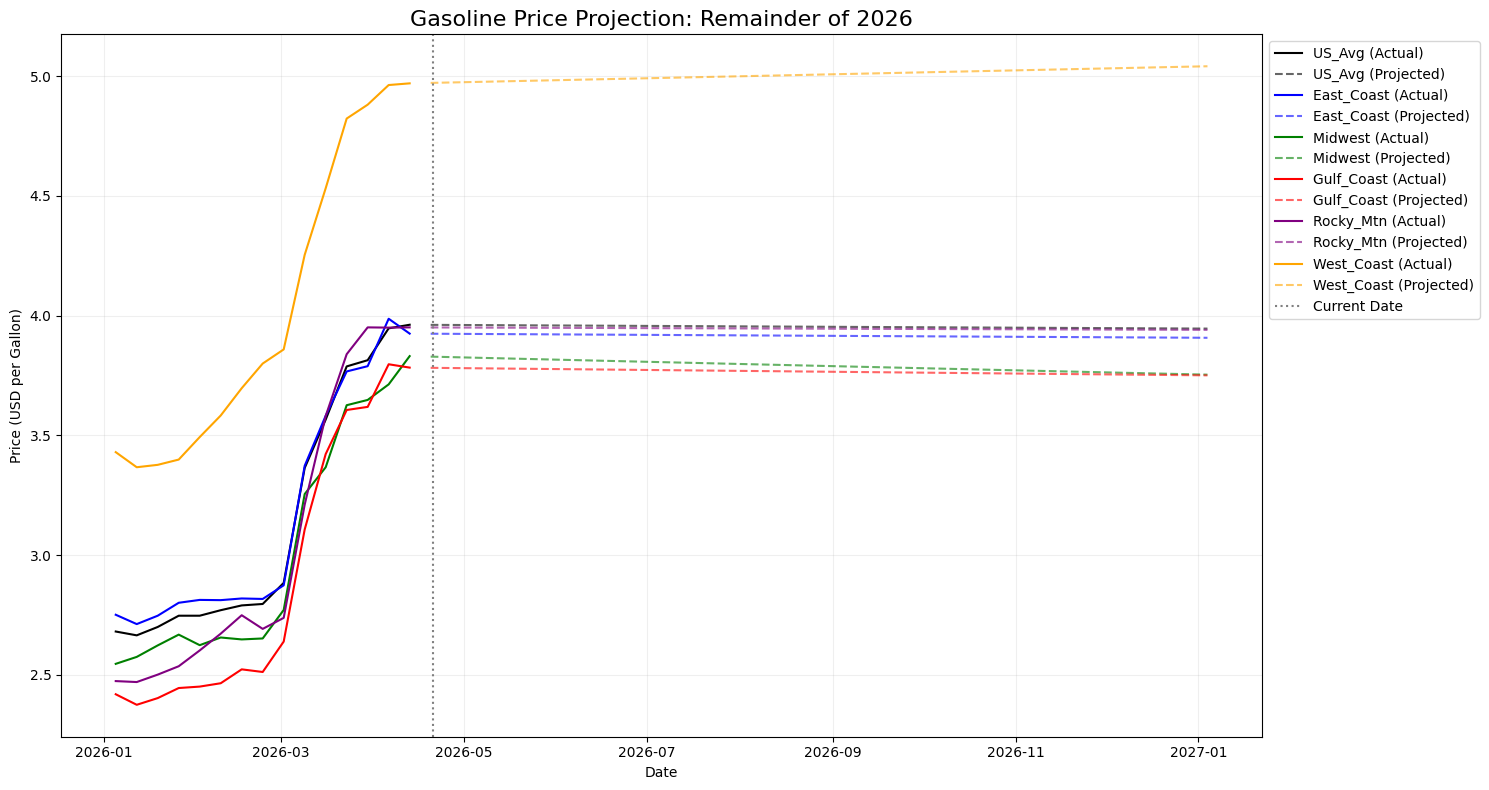

In [10]:
plt.figure(figsize=(15, 8))

colors = ['black', 'blue', 'green', 'red', 'purple', 'orange']

for i, r in enumerate(regions):
    # Plot Actuals (Jan 2026 to Now)
    actual_2026 = df[df['Date'].dt.year == 2026]
    plt.plot(actual_2026['Date'], actual_2026[r], color=colors[i], label=f'{r} (Actual)')

    # Plot Forecast (Now to Dec 2026)
    forecast_df = future_forecasts[r]
    plt.plot(forecast_df['Date'], forecast_df['Price'], color=colors[i], linestyle='--', alpha=0.6, label=f'{r} (Projected)')

plt.axvline(x=pd.to_datetime('today'), color='gray', linestyle=':', label='Current Date')
plt.title('Gasoline Price Projection: Remainder of 2026', fontsize=16)
plt.ylabel('Price (USD per Gallon)')
plt.xlabel('Date')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [11]:
import plotly.express as px
import pandas as pd

# 1. Get the most recent prices from your dataframe
latest_prices = df.iloc[-1]

# 2. Define which states belong to which EIA Region
region_map = {
    'East_Coast': ['ME', 'NH', 'VT', 'MA', 'RI', 'CT', 'NY', 'NJ', 'PA', 'DE', 'MD', 'DC', 'VA', 'WV', 'NC', 'SC', 'GA', 'FL'],
    'Midwest': ['ND', 'SD', 'NE', 'KS', 'OK', 'MN', 'IA', 'MO', 'WI', 'IL', 'MI', 'IN', 'OH', 'KY', 'TN'],
    'Gulf_Coast': ['NM', 'TX', 'AR', 'LA', 'MS', 'AL'],
    'Rocky_Mtn': ['ID', 'MT', 'WY', 'UT', 'CO'],
    'West_Coast': ['WA', 'OR', 'CA', 'NV', 'AZ', 'AK', 'HI']
}

# 3. Build a state-level dataframe for the map
map_data = []
for region, states in region_map.items():
    price = latest_prices[region]
    for state in states:
        map_data.append({'State': state, 'Price': price, 'Region': region.replace('_', ' ')})

df_map = pd.DataFrame(map_data)

# 4. Create the Interactive Choropleth Map
fig = px.choropleth(
    df_map,
    locations='State',
    locationmode="USA-states",
    color='Price',
    scope="usa",
    color_continuous_scale="RdYlGn_r", # Red for high prices, Green for low
    title=f"Current Gasoline Prices by Region ({df['Date'].max().strftime('%b %d, %2026')})",
    labels={'Price': 'USD per Gallon'},
    hover_data=['Region']
)

fig.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    geo=dict(bgcolor= 'rgba(0,0,0,0)', lakecolor='rgb(255, 255, 255)')
)

fig.show()

In [12]:
import plotly.express as px
import pandas as pd

# 1. Filter the data specifically for January 2026
df_jan_2026 = df[(df['Date'].dt.year == 2026) & (df['Date'].dt.month == 1)]

# 2. Calculate the average price for each region during that month
jan_2026_avgs = df_jan_2026.mean(numeric_only=True)

# 3. Use the regional mapping
region_map = {
    'East_Coast': ['ME', 'NH', 'VT', 'MA', 'RI', 'CT', 'NY', 'NJ', 'PA', 'DE', 'MD', 'DC', 'VA', 'WV', 'NC', 'SC', 'GA', 'FL'],
    'Midwest': ['ND', 'SD', 'NE', 'KS', 'OK', 'MN', 'IA', 'MO', 'WI', 'IL', 'MI', 'IN', 'OH', 'KY', 'TN'],
    'Gulf_Coast': ['NM', 'TX', 'AR', 'LA', 'MS', 'AL'],
    'Rocky_Mtn': ['ID', 'MT', 'WY', 'UT', 'CO'],
    'West_Coast': ['WA', 'OR', 'CA', 'NV', 'AZ', 'AK', 'HI']
}

# 4. Build the dataframe for January 2026
map_data_jan = []
for region, states in region_map.items():
    price = jan_2026_avgs[region]
    for state in states:
        map_data_jan.append({
            'State': state,
            'Price': price,
            'Region': region.replace('_', ' ')
        })

df_map_jan = pd.DataFrame(map_data_jan)

# 5. Generate the Map
fig = px.choropleth(
    df_map_jan,
    locations='State',
    locationmode="USA-states",
    color='Price',
    scope="usa",
    color_continuous_scale="Blues", # Using a 'Cold' color scale for January
    title="Historical Heatmap: Average Gasoline Prices (January 2026)",
    labels={'Price': 'Avg USD/Gallon'},
    hover_data=['Region']
)

fig.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    geo=dict(bgcolor= 'rgba(0,0,0,0)')
)

fig.show()

In [13]:
import plotly.express as px
import pandas as pd

# 1. Filter the data for April 2025
df_april_2025 = df[(df['Date'].dt.year == 2025) & (df['Date'].dt.month == 4)]

# 2. Calculate the average price for each region for that month
# This gives us a single representative price for "April 2025"
april_2025_avgs = df_april_2025.mean(numeric_only=True)

# 3. Define the state-to-region mapping (PADD Districts)
region_map = {
    'East_Coast': ['ME', 'NH', 'VT', 'MA', 'RI', 'CT', 'NY', 'NJ', 'PA', 'DE', 'MD', 'DC', 'VA', 'WV', 'NC', 'SC', 'GA', 'FL'],
    'Midwest': ['ND', 'SD', 'NE', 'KS', 'OK', 'MN', 'IA', 'MO', 'WI', 'IL', 'MI', 'IN', 'OH', 'KY', 'TN'],
    'Gulf_Coast': ['NM', 'TX', 'AR', 'LA', 'MS', 'AL'],
    'Rocky_Mtn': ['ID', 'MT', 'WY', 'UT', 'CO'],
    'West_Coast': ['WA', 'OR', 'CA', 'NV', 'AZ', 'AK', 'HI']
}

# 4. Build the mapping dataframe
map_data_2025 = []
for region, states in region_map.items():
    price = april_2025_avgs[region]
    for state in states:
        map_data_2025.append({
            'State': state,
            'Price': price,
            'Region': region.replace('_', ' ')
        })

df_map_2025 = pd.DataFrame(map_data_2025)

# 5. Create the Heatmap
fig = px.choropleth(
    df_map_2025,
    locations='State',
    locationmode="USA-states",
    color='Price',
    scope="usa",
    color_continuous_scale="YlOrRd", # Yellow to Red heatmap style
    title="Historical Heatmap: Average Gasoline Prices (April 2025)",
    labels={'Price': 'Avg USD/Gallon'},
    hover_data=['Region']
)

fig.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    geo=dict(bgcolor= 'rgba(0,0,0,0)')
)

fig.show()


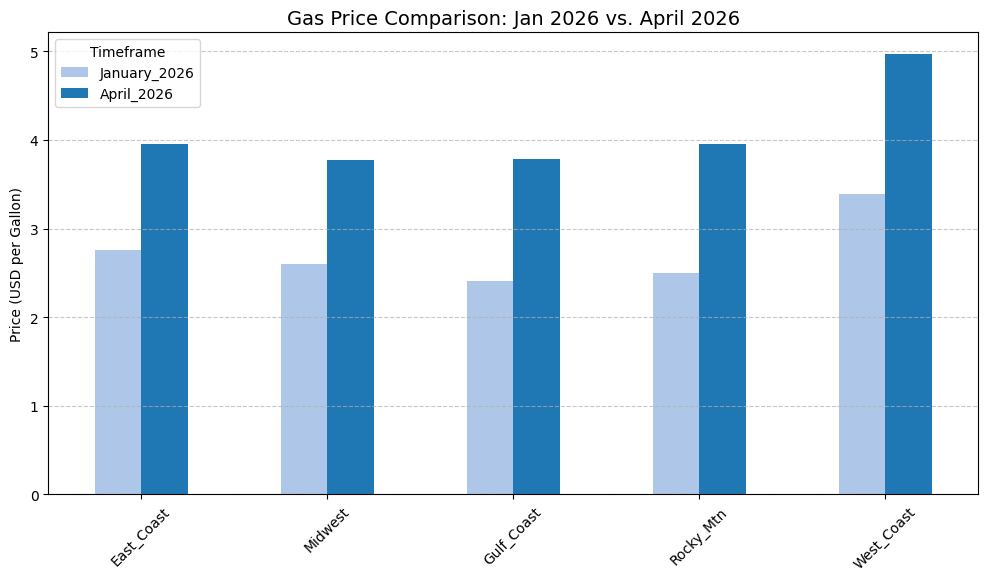

Regional Price Change Analysis:
            January_2026  April_2026  Dollar_Change  Percent_Increase
East_Coast         2.753       3.956          1.203            43.711
Midwest            2.603       3.772          1.169            44.910
Gulf_Coast         2.411       3.790          1.379            57.229
Rocky_Mtn          2.495       3.950          1.455            58.321
West_Coast         3.393       4.966          1.573            46.364


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Filter and Average for January 2026
jan_2026 = df[(df['Date'].dt.year == 2026) & (df['Date'].dt.month == 1)].mean(numeric_only=True)

# 2. Filter and Average for April 2026
# (Note: This will use all available weeks in April up to the current date)
apr_2026 = df[(df['Date'].dt.year == 2026) & (df['Date'].dt.month == 4)].mean(numeric_only=True)

# 3. Create a Comparison DataFrame
comparison_df = pd.DataFrame({
    'January_2026': jan_2026,
    'April_2026': apr_2026
})

# 4. Calculate the Dollar Change and Percentage Change
comparison_df['Dollar_Change'] = comparison_df['April_2026'] - comparison_df['January_2026']
comparison_df['Percent_Increase'] = (comparison_df['Dollar_Change'] / comparison_df['January_2026']) * 100

# Remove the US_Avg if you just want to see the regions
comparison_regions = comparison_df.drop('US_Avg')

# 5. Visualize the comparison
comparison_regions[['January_2026', 'April_2026']].plot(kind='bar', figsize=(12, 6), color=['#aec7e8', '#1f77b4'])
plt.title('Gas Price Comparison: Jan 2026 vs. April 2026', fontsize=14)
plt.ylabel('Price (USD per Gallon)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Timeframe")
plt.show()

# Print the table for your report
print("Regional Price Change Analysis:")
print(comparison_regions[['January_2026', 'April_2026', 'Dollar_Change', 'Percent_Increase']].round(3))

In [15]:
# dollar change from jan to apr 2026
import plotly.express as px
import pandas as pd

# 1. Calculate Averages for both months
jan_2026_avg = df[(df['Date'].dt.year == 2026) & (df['Date'].dt.month == 1)].mean(numeric_only=True)
apr_2026_avg = df[(df['Date'].dt.year == 2026) & (df['Date'].dt.month == 4)].mean(numeric_only=True)

# 2. Calculate the Dollar Change (April minus January)
dollar_change = apr_2026_avg - jan_2026_avg

# 3. Use the regional mapping (PADD Districts)
region_map = {
    'East_Coast': ['ME', 'NH', 'VT', 'MA', 'RI', 'CT', 'NY', 'NJ', 'PA', 'DE', 'MD', 'DC', 'VA', 'WV', 'NC', 'SC', 'GA', 'FL'],
    'Midwest': ['ND', 'SD', 'NE', 'KS', 'OK', 'MN', 'IA', 'MO', 'WI', 'IL', 'MI', 'IN', 'OH', 'KY', 'TN'],
    'Gulf_Coast': ['NM', 'TX', 'AR', 'LA', 'MS', 'AL'],
    'Rocky_Mtn': ['ID', 'MT', 'WY', 'UT', 'CO'],
    'West_Coast': ['WA', 'OR', 'CA', 'NV', 'AZ', 'AK', 'HI']
}

# 4. Build the mapping dataframe for the "Change" metric
change_map_data = []
for region, states in region_map.items():
    # Get the dollar change for this specific region
    change_value = dollar_change[region]
    for state in states:
        change_map_data.append({
            'State': state,
            'Dollar_Change': change_value,
            'Region': region.replace('_', ' ')
        })

df_change_map = pd.DataFrame(change_map_data)

# 5. Generate the Choropleth Map
fig = px.choropleth(
    df_change_map,
    locations='State',
    locationmode="USA-states",
    color='Dollar_Change',
    scope="usa",
    color_continuous_scale="OrRd", # Orange to Red highlights the increase
    title="Price Surge: Dollar Increase in Gas Prices (Jan 2026 vs. April 2026)",
    labels={'Dollar_Change': 'Increase ($/Gallon)'},
    hover_data=['Region']
)

fig.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    geo=dict(bgcolor= 'rgba(0,0,0,0)')
)

fig.show()

In [16]:
# Model Accuracy
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# 1. Prepare the data (Using US_Avg as an example)
data = region_data['US_Avg'].copy()
data['Lag1'] = data['Price'].shift(1)
data = data.dropna()

# 2. Split into Train and Test
# We'll use the last 52 weeks to test the model's accuracy
train = data.iloc[:-52]
test = data.iloc[-52:]

X_train = train[['Lag1']]
y_train = train['Price']
X_test = test[['Lag1']]
y_test = test['Price']

# 3. Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Create Predictions
predictions = model.predict(X_test)

# 5. Evaluate (This part was causing your error)
mae = mean_absolute_error(y_test, predictions)
r2 = model.score(X_test, y_test)

print(f"Model Accuracy Metrics for US Average:")
print(f"- Mean Absolute Error: ${mae:.4f}")
print(f"- R-squared Score: {r2:.4f}")

Model Accuracy Metrics for US Average:
- Mean Absolute Error: $0.0456
- R-squared Score: 0.9108


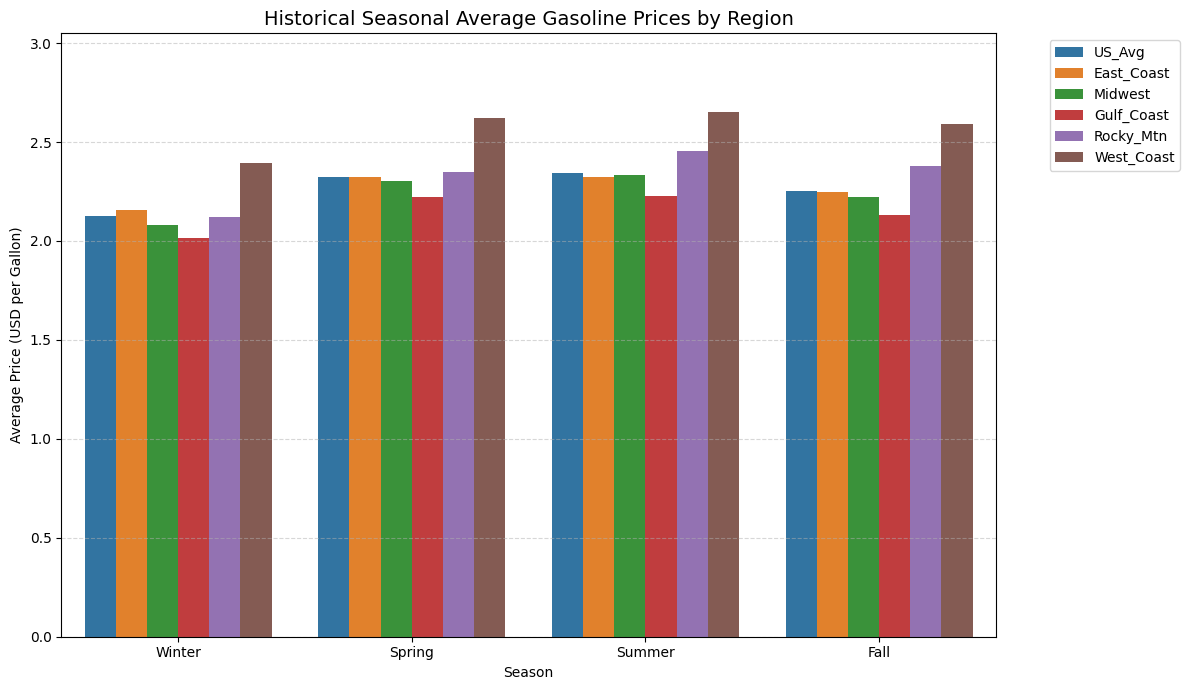

Average Price per Season:
        US_Avg  East_Coast  Midwest  Gulf_Coast  Rocky_Mtn  West_Coast
Season                                                                
Winter   2.125       2.157    2.082       2.015      2.119       2.392
Spring   2.326       2.324    2.301       2.221      2.351       2.622
Summer   2.344       2.321    2.332       2.227      2.455       2.652
Fall     2.254       2.250    2.222       2.130      2.377       2.591


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the Season Logic
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

# 2. Apply the logic to your dataset
df['Month'] = df['Date'].dt.month
df['Season'] = df['Month'].apply(get_season)

# 3. Calculate the averages per season for each region
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
# We group by 'Season' and take the mean of the price columns
seasonal_avg = df.groupby('Season')[['US_Avg', 'East_Coast', 'Midwest', 'Gulf_Coast', 'Rocky_Mtn', 'West_Coast']].mean().reindex(season_order)

# 4. Prepare data for a Grouped Bar Chart
# We 'melt' the data to make it compatible with Seaborn's barplot
seasonal_plot_df = seasonal_avg.reset_index().melt(id_vars='Season', var_name='Region', value_name='Average_Price')

# 5. Create the Visualization
plt.figure(figsize=(12, 7))
sns.barplot(data=seasonal_plot_df, x='Season', y='Average_Price', hue='Region')

plt.title('Historical Seasonal Average Gasoline Prices by Region', fontsize=14)
plt.ylabel('Average Price (USD per Gallon)')
plt.xlabel('Season')
plt.ylim(0, seasonal_plot_df['Average_Price'].max() * 1.15) # Leave room for the legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Display the numerical table for your report
print("Average Price per Season:")
print(seasonal_avg.round(3))